### Topic Labels cleaning

- Remove duplicate `id` values, fully empty rows, and rows with missing or invalid `id` (16 hex chars, matching `export_unige_emails` hashes).
- Drop rows that **miss too many annotations**: fewer than `MIN_COMPLETE_MODELS` of `{ge, cl, gpt}` have a full set (topic label, priority label, both confidences, non-empty rationale). Default `MIN_COMPLETE_MODELS = 2` (set to `3` to require every model complete).

Output: `annotation_dataset_clean.csv`.

In [1]:
import pandas as pd
import re
path = '../data/annotation/annotation_dataset.csv'
df = pd.read_csv(path)
print('shape', df.shape)
print('columns', list(df.columns[:5]), '...')
print('id null', df['id'].isna().sum())
print('id empty str', (df['id'].astype(str).str.strip() == '').sum())
print('duplicate id count', df['id'].duplicated().sum())
# valid id: 16 hex (from export script hash[:16])
pat = re.compile(r'^[0-9a-fA-F]{16}$')
ids = df['id'].astype(str).str.strip()
valid = ids.apply(lambda x: bool(pat.match(x)))
print('invalid id', (~valid).sum())
print('sample invalid', df.loc[~valid, 'id'].head(20).tolist())
# fully empty rows
all_na = df.isna().all(axis=1)
print('all-NA rows', all_na.sum())

shape (940, 22)
columns ['batch', 'id', 'ge_topic_label', 'ge_topic_confidence', 'ge_priority_label'] ...
id null 0
id empty str 0
duplicate id count 1
invalid id 0
sample invalid []
all-NA rows 0


In [2]:
ID_PATTERN = re.compile(r"^[0-9a-fA-F]{16}$")
MIN_COMPLETE_MODELS = 2  # require this many of ge/cl/gpt to be fully annotated; use 3 for strict


def _is_blank(s) -> bool:
    if pd.isna(s):
        return True
    t = str(s).strip()
    return t == "" or t.lower() == "nan"


def _model_complete(row: pd.Series, prefix: str) -> bool:
    if _is_blank(row.get(f"{prefix}_topic_label")) or _is_blank(row.get(f"{prefix}_priority_label")):
        return False
    if pd.isna(row.get(f"{prefix}_topic_confidence")) or pd.isna(row.get(f"{prefix}_priority_confidence")):
        return False
    if _is_blank(row.get(f"{prefix}_short_rationale")):
        return False
    return True


df_clean = df.copy()

# Drop rows that are entirely empty
df_clean = df_clean.dropna(how="all")

# Keep only rows with a valid id
id_str = df_clean["id"].astype(str).str.strip()
bad_id = (
    df_clean["id"].isna()
    | (id_str == "")
    | (id_str.str.lower() == "nan")
    | ~id_str.apply(lambda x: bool(ID_PATTERN.match(x)))
)
n_invalid = int(bad_id.sum())
df_clean = df_clean.loc[~bad_id].copy()

# Duplicate ids: keep first occurrence
n_dup = int(df_clean["id"].duplicated().sum())
df_clean = df_clean.drop_duplicates(subset=["id"], keep="first")

# All main text fields (rationales) empty — ge / cl / gpt short rationale
all_text_empty = (
    df_clean["ge_short_rationale"].map(_is_blank)
    & df_clean["cl_short_rationale"].map(_is_blank)
    & df_clean["gpt_short_rationale"].map(_is_blank)
)
n_all_text_empty = int(all_text_empty.sum())
df_clean = df_clean.loc[~all_text_empty].copy()

# Too few fully complete model annotations
complete_counts = df_clean.apply(
    lambda r: sum(_model_complete(r, p) for p in ("ge", "cl", "gpt")),
    axis=1,
)
sparse = complete_counts < MIN_COMPLETE_MODELS
n_sparse = int(sparse.sum())
df_clean = df_clean.loc[~sparse].copy()

out_path = "../data/annotation/annotation_dataset_clean.csv"
df_clean.to_csv(out_path, index=False, encoding="utf-8-sig")

print(f"Removed invalid/missing id rows: {n_invalid}")
print(f"Removed duplicate id rows (extras): {n_dup}")
print(f"Removed all-main-text-empty rows: {n_all_text_empty}")
print(f"Removed sparse annotation rows (< {MIN_COMPLETE_MODELS} complete models): {n_sparse}")
print(f"Final shape: {df_clean.shape}")
print(f"Saved: {out_path}")

Removed invalid/missing id rows: 0
Removed duplicate id rows (extras): 1
Removed all-main-text-empty rows: 0
Removed sparse annotation rows (< 2 complete models): 0
Final shape: (939, 22)
Saved: annotation_dataset_clean.csv


In [7]:
# Run after cell 2 — uses `df_clean` and `_is_blank`

cl_topic_empty = df_clean["cl_topic_label"].map(_is_blank)
cl_priority_empty = df_clean["cl_priority_label"].map(_is_blank)
cl_either_empty = cl_topic_empty | cl_priority_empty

print("cl_topic_label empty:", int(cl_topic_empty.sum()))
print("cl_priority_label empty:", int(cl_priority_empty.sum()))
print("rows with either CL label empty:", int(cl_either_empty.sum()))

if cl_either_empty.any():
    display(df_clean.loc[cl_either_empty, ["id", "batch", "cl_topic_label", "cl_priority_label"]])

cl_topic_label empty: 1
cl_priority_label empty: 1
rows with either CL label empty: 1


,id,batch,cl_topic_label,cl_priority_label
122,65f36002e71bc430,3,Administrative,High


### Removing the `Other` label

The report drops the `Other` topic class. Here that is done in two ways: when a row has 2/3 agreement and one model still says `Other`, the `Other` is replaced by the consensus label; the remaining `Other` cases are resolved manually below.

In [8]:
# Rows where any model's topic is "Other" (case-insensitive). Run after cell 2.

def _label_is_other(s) -> bool:
    if pd.isna(s):
        return False
    return str(s).strip().lower() == "other"


_mask_other = (
    df_clean["ge_topic_label"].map(_label_is_other)
    | df_clean["cl_topic_label"].map(_label_is_other)
    | df_clean["gpt_topic_label"].map(_label_is_other)
)

_show_cols = ["batch", "id", "ge_topic_label", "cl_topic_label", "gpt_topic_label"]
n_other = int(_mask_other.sum())
print(f"Rows with Other in ge/cl/gpt topic_label: {n_other}")

if n_other:
    display(df_clean.loc[_mask_other, _show_cols].sort_values(["batch", "id"]))
else:
    print("No matching rows.")

Rows with Other in ge/cl/gpt topic_label: 49


,batch,id,ge_topic_label,cl_topic_label,gpt_topic_label
17,1,5392b75b55ff1e8f,Administrative,Other,Administrative
22,1,6851b4a5be99a46d,Administrative,Other,Administrative
34,1,a36b77d5dcf48d8a,Advertisement,Other,Advertisement
99,2,feba57a55892c477,Course-exam,Other,Course-exam
142,3,d95d01faef4fbff7,Deadline-action,Other,Deadline-action
211,5,3ea882510954a863,Administrative,Other,Administrative
292,6,f30360a6ceac16bc,Administrative,Other,Advertisement
327,7,839b0424f7bb8348,Event,Other,Course-exam
344,7,dc580d2a74313b43,Event,Other,Course-exam
359,8,20c71ed182fc73ca,Administrative,Other,Other


In [9]:
# When topic_agreement_count == 2 and any ge/cl/gpt topic is "Other", set that "Other" to topic_consensus_label.
# Step 1: new dataframe + before/after preview. Run after cell 2.

TOPIC_COLS = ["ge_topic_label", "cl_topic_label", "gpt_topic_label"]


def _label_is_other_topic(s) -> bool:
    if pd.isna(s):
        return False
    return str(s).strip().lower() == "other"


df_before_topic_fix = df_clean.copy()
df_topic_other_fixed = df_clean.copy()

cons = df_topic_other_fixed["topic_consensus_label"]
cons_ok = cons.notna() & (cons.astype(str).str.strip().str.lower() != "other")

eligible_topic_fix = (
    (df_topic_other_fixed["topic_agreement_count"] == 2)
    & cons_ok
    & df_topic_other_fixed[TOPIC_COLS].apply(lambda col: col.map(_label_is_other_topic)).any(axis=1)
)

n_fix = int(eligible_topic_fix.sum())
print(
    f"Rows to fix (topic_agreement_count==2, consensus not Other, at least one Other in {TOPIC_COLS}): {n_fix}"
)

_compare = ["batch", "id", "topic_agreement_count", "topic_consensus_label"] + TOPIC_COLS

if n_fix:
    print("\nBefore:")
    display(df_before_topic_fix.loc[eligible_topic_fix, _compare].sort_values(["batch", "id"]))

    for col in TOPIC_COLS:
        other_m = df_topic_other_fixed[col].map(_label_is_other_topic)
        to_fix = eligible_topic_fix & other_m
        df_topic_other_fixed.loc[to_fix, col] = df_topic_other_fixed.loc[to_fix, "topic_consensus_label"]

    print("\nAfter (df_topic_other_fixed):")
    display(df_topic_other_fixed.loc[eligible_topic_fix, _compare].sort_values(["batch", "id"]))
else:
    print("No rows matched; df_topic_other_fixed is a copy of df_clean.")

Rows to fix (topic_agreement_count==2, consensus not Other, at least one Other in ['ge_topic_label', 'cl_topic_label', 'gpt_topic_label']): 19

Before:


,batch,id,topic_agreement_count,topic_consensus_label,ge_topic_label,cl_topic_label,gpt_topic_label
17,1,5392b75b55ff1e8f,2,Administrative,Administrative,Other,Administrative
22,1,6851b4a5be99a46d,2,Administrative,Administrative,Other,Administrative
34,1,a36b77d5dcf48d8a,2,Advertisement,Advertisement,Other,Advertisement
99,2,feba57a55892c477,2,Course-exam,Course-exam,Other,Course-exam
142,3,d95d01faef4fbff7,2,Deadline-action,Deadline-action,Other,Deadline-action
211,5,3ea882510954a863,2,Administrative,Administrative,Other,Administrative
367,8,4eae15799f8c3dc8,2,Course-exam,Course-exam,Other,Course-exam
388,8,ddcad2f9ebd98a27,2,Course-exam,Course-exam,Other,Course-exam
396,8,f0625e10661d00a3,2,Deadline-action,Deadline-action,Other,Deadline-action
457,10,28abec6fbdce7698,2,Administrative,Administrative,Other,Administrative



After (df_topic_other_fixed):


,batch,id,topic_agreement_count,topic_consensus_label,ge_topic_label,cl_topic_label,gpt_topic_label
17,1,5392b75b55ff1e8f,2,Administrative,Administrative,Administrative,Administrative
22,1,6851b4a5be99a46d,2,Administrative,Administrative,Administrative,Administrative
34,1,a36b77d5dcf48d8a,2,Advertisement,Advertisement,Advertisement,Advertisement
99,2,feba57a55892c477,2,Course-exam,Course-exam,Course-exam,Course-exam
142,3,d95d01faef4fbff7,2,Deadline-action,Deadline-action,Deadline-action,Deadline-action
211,5,3ea882510954a863,2,Administrative,Administrative,Administrative,Administrative
367,8,4eae15799f8c3dc8,2,Course-exam,Course-exam,Course-exam,Course-exam
388,8,ddcad2f9ebd98a27,2,Course-exam,Course-exam,Course-exam,Course-exam
396,8,f0625e10661d00a3,2,Deadline-action,Deadline-action,Deadline-action,Deadline-action
457,10,28abec6fbdce7698,2,Administrative,Administrative,Administrative,Administrative


In [11]:
# Step 2: persist fixed topics to annotation_dataset_clean.csv and align df_clean.

clean_path = "../data/annotation/annotation_dataset_clean.csv"
df_topic_other_fixed.to_csv(clean_path, index=False, encoding="utf-8-sig")
df_clean = df_topic_other_fixed
print(f"Wrote {clean_path} ({len(df_clean)} rows). df_clean now matches the file.")

Wrote annotation_dataset_clean.csv (939 rows). df_clean now matches the file.



ge_topic_label — counts (missing as NaN row if any):


ge_topic_label
Course-exam        263
Event              186
Administrative     180
Deadline-action    175
Advertisement      124
Other               10
NaN                  1
Name: count, dtype: int64


cl_topic_label — counts (missing as NaN row if any):


cl_topic_label
Course-exam        278
Event              185
Administrative     166
Deadline-action    159
Advertisement      108
Other               28
NaN                 15
Name: count, dtype: int64


gpt_topic_label — counts (missing as NaN row if any):


gpt_topic_label
Course-exam        266
Deadline-action    244
Event              181
Advertisement      115
Administrative     114
Other               19
Name: count, dtype: int64

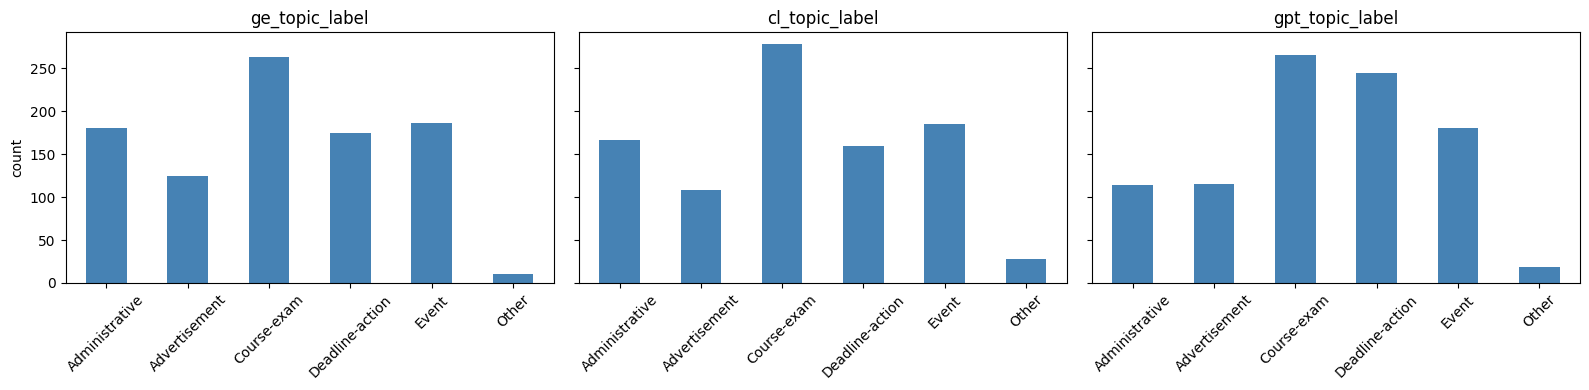

In [12]:
# Distribution of topic labels: ge vs cl vs gpt. Run after `df_clean` is ready.

_label_cols = ["ge_topic_label", "cl_topic_label", "gpt_topic_label"]

for c in _label_cols:
    print(f"\n{c} — counts (missing as NaN row if any):")
    display(df_clean[c].value_counts(dropna=False))

# Side-by-side bar charts (same label order = sorted union of all labels)
import matplotlib.pyplot as plt

all_labels = sorted(
    set().union(*[df_clean[c].dropna().astype(str).unique().tolist() for c in _label_cols])
)
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, c in zip(axes, _label_cols):
    counts = df_clean[c].value_counts().reindex(all_labels, fill_value=0)
    counts.plot(kind="bar", ax=ax, color="steelblue", rot=45, legend=False)
    ax.set_title(c)
    ax.set_xlabel("")
    ax.set_ylabel("count")
plt.tight_layout()
plt.show()

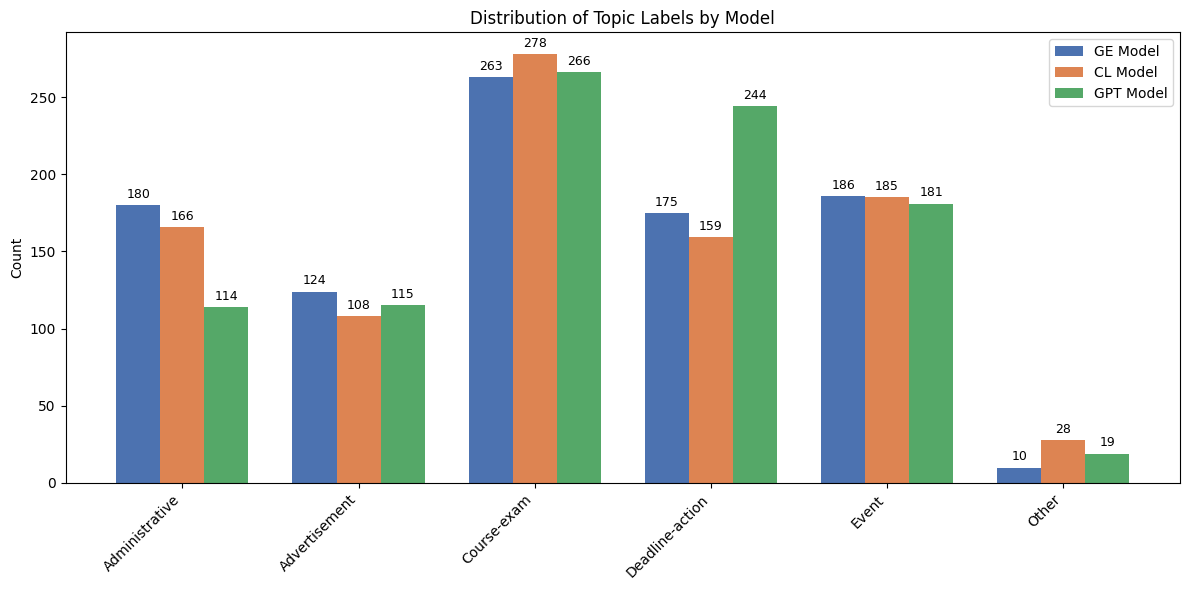

In [1]:
# === APPENDIX (optional, beyond report scope): static snapshot duplicating the live GE/CL/GPT topic chart above ===
import matplotlib.pyplot as plt
import numpy as np

# Define the categories (classes)
categories = ['Administrative', 'Advertisement', 'Course-exam', 'Deadline-action', 'Event', 'Other']

# Define the counts for each model based on the provided data (excluding NaN)
ge_counts = [180, 124, 263, 175, 186, 10]
cl_counts = [166, 108, 278, 159, 185, 28]
gpt_counts = [114, 115, 266, 244, 181, 19]

# Set up the x locations for the groups
x = np.arange(len(categories))

# Set the width of the bars
width = 0.25

# Create the figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the bars for each model, shifting their x positions to group them
rects1 = ax.bar(x - width, ge_counts, width, label='GE Model', color='#4c72b0')
rects2 = ax.bar(x, cl_counts, width, label='CL Model', color='#dd8452')
rects3 = ax.bar(x + width, gpt_counts, width, label='GPT Model', color='#55a868')

# Add labels, title, and custom x-axis tick labels
ax.set_ylabel('Count')
ax.set_title('Distribution of Topic Labels by Model')
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=45, ha='right')
ax.legend()

# Optional: Add value labels on top of the bars for exact numbers
def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

# Adjust layout to prevent clipping of tick-labels
fig.tight_layout()

# Display the plot
plt.show()

### manually annotating low consensus emails

In [3]:
from IPython.display import display

df = pd.read_csv("../data/annotation/annotation_dataset_clean.csv")
low_agreement = df[df["topic_agreement_count"] == 1]

topic_cols = [
    "ge_topic_label",
    "ge_short_rationale",
    "cl_topic_label",
    "cl_short_rationale",
    "gpt_topic_label",
    "gpt_short_rationale",
]
view = low_agreement[["id"] + topic_cols].copy()

rationale_cols = ["ge_short_rationale", "cl_short_rationale", "gpt_short_rationale"]
label_cols = ["ge_topic_label", "cl_topic_label", "gpt_topic_label"]

# Explicit colors on stripes so light rows get dark text (fixes dark-theme Jupyter)
styled = (
    view.style.set_properties(
        subset=rationale_cols,
        **{
            "text-align": "left",
            "white-space": "pre-wrap",
            "word-break": "break-word",
            "max-width": "36rem",
        },
    )
    .set_properties(
        subset=["id"] + label_cols,
        **{"vertical-align": "top", "white-space": "nowrap"},
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "left"),
                    ("vertical-align", "top"),
                    ("background-color", "#334155"),
                    ("color", "#f8fafc"),
                ],
            },
            {
                "selector": "tbody tr:nth-child(odd) td",
                "props": [
                    ("background-color", "#1e293b"),
                    ("color", "#e2e8f0"),
                ],
            },
            {
                "selector": "tbody tr:nth-child(even) td",
                "props": [
                    ("background-color", "#f1f5f9"),
                    ("color", "#0f172a"),
                ],
            },
            {"selector": "table", "props": [("width", "100%"), ("border-collapse", "collapse")]},
        ],
        overwrite=False,
    )
)

display(styled)


,id,ge_topic_label,ge_short_rationale,cl_topic_label,cl_short_rationale,gpt_topic_label,gpt_short_rationale


### Manual topic corrections (low-consensus emails)

Gold `*_topic_label` for selected `id` values; rows marked **Remove** are dropped. Then `annotation_dataset_clean.csv` is overwritten.

Run after `df_clean` exists (cleaning cells), or the cell loads the CSV if `df_clean` is missing.


In [3]:
try:
    df_clean = df_clean.copy()
except NameError:
    df_clean = pd.read_csv("../data/annotation/annotation_dataset_clean.csv")

MANUAL_TOPIC_BY_ID = {
    "db9cd5c8ae3eb13a": "Advertisement",
    "3914c64b5e1ceda8": "Advertisement",
    "fc2a8d44d0faef4a": "Deadline-action",
    "087e7ba1e3eb2f7c": "Event",
    "d23c6ced1d910fc4": "Event",
    "e74100ea83797937": "Advertisement",
    "f30360a6ceac16bc": "Administrative",
    "839b0424f7bb8348": "Course-exam",
    "dc580d2a74313b43": "Course-exam",
    "375babc667116204": "Deadline-action",
    "54926be432ba4a52": "Administrative",
    "d868dd4be5be5a72": "Administrative",
    "8dedd0d06823981b": "Administrative",
    "0a7a57e6a5093108": "Event",
    "a511f530589b89c3": "Administrative",
    "977aeef48c975271": "Deadline-action",
}
REMOVE_IDS = {
    "5f09294b1b57e3ce",
    "c98779cd0d7146b8",
    "f875ad1e033874b1",
}

def data_cleaner(df_clean,  MANUAL_TOPIC_BY_ID, REMOVE_IDS):
    _topic_triple = ["ge_topic_label", "cl_topic_label", "gpt_topic_label"]
    _ids_present = set(df_clean["id"].astype(str))

    for eid, label in MANUAL_TOPIC_BY_ID.items():
        if eid not in _ids_present:
            print(f"[warn] id not in table (skip update): {eid}")
            continue
        m = df_clean["id"].astype(str) == eid
        df_clean.loc[m, _topic_triple] = label
        df_clean.loc[m, "topic_consensus_label"] = label
        df_clean.loc[m, "topic_agreement_count"] = 3

    for eid in REMOVE_IDS:
        if eid not in _ids_present:
            print(f"[warn] remove id not in table: {eid}")

    _n = len(df_clean)
    df_clean = df_clean[~df_clean["id"].astype(str).isin(REMOVE_IDS)].reset_index(drop=True)
    print(f"Removed {_n - len(df_clean)} row(s); table now has {len(df_clean)} rows.")

    out_manual = "../data/annotation/annotation_dataset_clean.csv"
    df_clean.to_csv(out_manual, index=False, encoding="utf-8-sig")
    print(f"Saved: {out_manual}")

    # Quick check: patched ids
    _check_ids = list(MANUAL_TOPIC_BY_ID.keys())
    display(
        df_clean[df_clean["id"].astype(str).isin(_check_ids)][["id", "batch"] + _topic_triple + ["topic_consensus_label", "topic_agreement_count"]].sort_values("id")
    )
    return df_clean

df_clean = data_cleaner(df_clean, MANUAL_TOPIC_BY_ID, REMOVE_IDS)

[warn] remove id not in table: c98779cd0d7146b8
[warn] remove id not in table: f875ad1e033874b1
[warn] remove id not in table: 5f09294b1b57e3ce
Removed 0 row(s); table now has 936 rows.
Saved: annotation_dataset_clean.csv


,id,batch,ge_topic_label,cl_topic_label,gpt_topic_label,topic_consensus_label,topic_agreement_count
201,087e7ba1e3eb2f7c,5,Event,Event,Event,Event,3
801,0a7a57e6a5093108,17,Event,Event,Event,Event,3
512,375babc667116204,11,Deadline-action,Deadline-action,Deadline-action,Deadline-action,3
160,3914c64b5e1ceda8,4,Advertisement,Advertisement,Advertisement,Advertisement,3
614,54926be432ba4a52,13,Administrative,Administrative,Administrative,Administrative,3
326,839b0424f7bb8348,7,Course-exam,Course-exam,Course-exam,Course-exam,3
778,8dedd0d06823981b,16,Administrative,Administrative,Administrative,Administrative,3
880,977aeef48c975271,18,Deadline-action,Deadline-action,Deadline-action,Deadline-action,3
830,a511f530589b89c3,17,Administrative,Administrative,Administrative,Administrative,3
242,d23c6ced1d910fc4,5,Event,Event,Event,Event,3


### Removing the last Other labels in ge_topic_labels

In [6]:
df_clean = pd.read_csv("../data/annotation/annotation_dataset_clean.csv")
MANUAL_TOPIC_BY_ID = {
    "a9539cc3b5fc00bf": "Administrative",
    "d6bb6d0fff52b99a": "Administrative",
    "e69675e2a5f6bfa8": "Event"

}
REMOVE_IDS = {
    "6a4ca87d9f64d676",
    "794e7eda5a3f90ad",
    "83e02f9c7643ce99",
    "e52f4273fc0db7f5",
    "ecbd1857a2f0c186"
}
df_clean = data_cleaner(df_clean, MANUAL_TOPIC_BY_ID, REMOVE_IDS)

[warn] remove id not in table: 794e7eda5a3f90ad
[warn] remove id not in table: e52f4273fc0db7f5
[warn] remove id not in table: ecbd1857a2f0c186
[warn] remove id not in table: 83e02f9c7643ce99
[warn] remove id not in table: 6a4ca87d9f64d676
Removed 0 row(s); table now has 931 rows.
Saved: annotation_dataset_clean.csv


,id,batch,ge_topic_label,cl_topic_label,gpt_topic_label,topic_consensus_label,topic_agreement_count
725,a9539cc3b5fc00bf,15,Administrative,Administrative,Administrative,Administrative,3
733,d6bb6d0fff52b99a,15,Administrative,Administrative,Administrative,Administrative,3
690,e69675e2a5f6bfa8,14,Event,Event,Event,Event,3


In [11]:
# === APPENDIX (optional, beyond report scope): per-model review of remaining "Other" labels ===
df = pd.read_csv("../data/annotation/annotation_dataset_clean.csv")
low_agreement = df[df["gpt_topic_label"] == "Other"]

topic_cols = [
    "ge_topic_label",
    "ge_short_rationale",
    "cl_topic_label",
    "cl_short_rationale",
    "gpt_topic_label",
    "gpt_short_rationale",
]
view = low_agreement[["id"] + topic_cols].copy()
view

,id,ge_topic_label,ge_short_rationale,cl_topic_label,cl_short_rationale,gpt_topic_label,gpt_short_rationale
358,20c71ed182fc73ca,Administrative,Time-sensitive verification email for an accou...,Other,Elsevier email verification message with no su...,Other,It is a third-party email verification message...
388,e7875413f5dd4eaa,Administrative,A time-sensitive automated login link for an e...,Other,Perplexity platform login verification link; t...,Other,It is a third-party sign-in verification email...
394,f5e1bf9e78caa2ad,Administrative,Automated welcome email following a registrati...,Other,Elsevier welcome email with empty body; generi...,Other,It is a generic third-party welcome email unre...
551,1a20537e37524a93,Administrative,It is a time-sensitive security code required ...,Other,One-time security passcode email; transactiona...,Other,It requires immediate use of a one-time passco...
558,3a5dc271c2d28837,Administrative,It is a time-sensitive security code for accou...,Other,Autodesk one-time security passcode in German;...,Other,It is an account one-time passcode email requi...
578,8188a7b126f0418c,Administrative,Official response to a student request for aca...,Other,Professor email response about class ranking a...,Other,It is a personal reply stating that no class r...
594,ec7eba387425a332,Administrative,It is a time-sensitive security code for accou...,Other,Autodesk one-time security passcode; transacti...,Other,It contains a one-time passcode for account au...
596,1119a70c0c887017,Administrative,Verification process for a student discount se...,Other,Spotify student verification process notificat...,Other,"It requests account verification for Spotify, ..."
606,3f8623478ecadf6e,Administrative,Time-sensitive PIN code for a verification req...,Other,Samsung verification PIN code email with 15-mi...,Other,It provides a short-lived verification PIN for...
629,8f160e515ea0b576,Administrative,Communication regarding a request for a refere...,Other,Academic mentoring communication: professor's ...,Other,This is personal email correspondence about a ...


In [12]:
df_clean = pd.read_csv("../data/annotation/annotation_dataset_clean.csv")
MANUAL_TOPIC_BY_ID = {
    "8188a7b126f0418c": "Administrative",
    "8f160e515ea0b576": "Administrative",
    "8368fa7f5098ef26": "Administrative",
    "e49b2a709ff36e2d": "Administrative",
    "120608db9b5efb9c": "Administrative"

}
REMOVE_IDS = {
    "20c71ed182fc73ca",
    "e7875413f5dd4eaa",
    "f5e1bf9e78caa2ad",
    "1a20537e37524a93",
    "3a5dc271c2d28837",
    "ec7eba387425a332",
    "1119a70c0c887017",
    "3f8623478ecadf6e",
    "b7c6d3107881bcff",
    "267230ac3862f02f",
    "d16d79dd37d31ede"
}
df_clean = data_cleaner(df_clean, MANUAL_TOPIC_BY_ID, REMOVE_IDS)

Removed 11 row(s); table now has 920 rows.
Saved: annotation_dataset_clean.csv


,id,batch,ge_topic_label,cl_topic_label,gpt_topic_label,topic_consensus_label,topic_agreement_count
736,120608db9b5efb9c,16,Administrative,Administrative,Administrative,Administrative,3
573,8188a7b126f0418c,12,Administrative,Administrative,Administrative,Administrative,3
707,8368fa7f5098ef26,15,Administrative,Administrative,Administrative,Administrative,3
621,8f160e515ea0b576,13,Administrative,Administrative,Administrative,Administrative,3
730,e49b2a709ff36e2d,15,Administrative,Administrative,Administrative,Administrative,3


In [14]:
# === APPENDIX (optional, beyond report scope): per-model review of remaining "Other" labels ===
df = pd.read_csv("../data/annotation/annotation_dataset_clean.csv")
low_agreement = df[df["cl_topic_label"] == "Other"]

topic_cols = [
    "ge_topic_label",
    "ge_short_rationale",
    "cl_topic_label",
    "cl_short_rationale",
    "gpt_topic_label",
    "gpt_short_rationale",
]
view = low_agreement[["id"] + topic_cols].copy()
view

,id,ge_topic_label,ge_short_rationale,cl_topic_label,cl_short_rationale,gpt_topic_label,gpt_short_rationale


,GE_count,GE_pct,CL_count,CL_pct,GPT_count,GPT_pct
Administrative,172,18.72,173,19.07,123,13.37
Advertisement,125,13.60,109,12.02,109,11.85
Course-exam,259,28.18,279,30.76,265,28.80
Deadline-action,176,19.15,160,17.64,241,26.20
Event,187,20.35,186,20.51,182,19.78


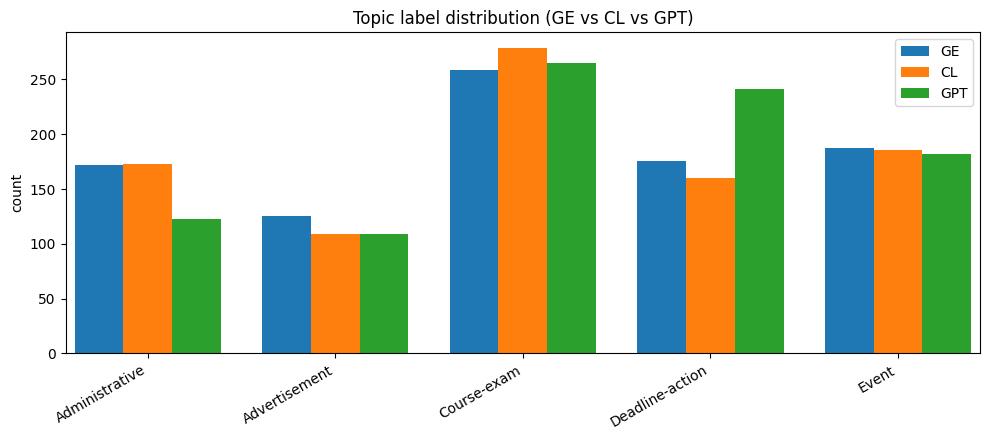

In [6]:
# === APPENDIX (optional, beyond report scope): re-run topic distribution summary (counts + %) after cleaning ===
# Distribution of topic labels for GE / CL / GPT (counts + %). Run anytime.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Use existing df_clean if present; otherwise load it
try:
    df_clean
except NameError:
    df_clean = pd.read_csv("../data/annotation/annotation_dataset_clean.csv")

label_cols = {
    "GE": "ge_topic_label",
    "CL": "cl_topic_label",
    "GPT": "gpt_topic_label",
}

# Union of labels (keep a stable, readable order)
all_labels = sorted(
    set().union(*[df_clean[c].dropna().astype(str).unique().tolist() for c in label_cols.values()])
)

# Build summary table: counts and % for each source
summary = pd.DataFrame(index=all_labels)
for src, col in label_cols.items():
    s = df_clean[col].astype("string")
    counts = s.value_counts(dropna=False)
    n = int(s.notna().sum())

    summary[f"{src}_count"] = counts.reindex(all_labels, fill_value=0).astype(int)
    summary[f"{src}_pct"] = (summary[f"{src}_count"] / max(n, 1) * 100).round(2)

display(summary)

# Plot: side-by-side counts per label
x = np.arange(len(all_labels))
width = 0.26

fig, ax = plt.subplots(figsize=(max(10, len(all_labels) * 1.2), 4.5))
for i, (src, _) in enumerate(label_cols.items()):
    ax.bar(x + (i - 1) * width, summary[f"{src}_count"].values, width, label=src)

ax.set_xticks(x)
ax.set_xticklabels(all_labels, rotation=30, ha="right")
ax.set_ylabel("count")
ax.set_title("Topic label distribution (GE vs CL vs GPT)")
ax.legend()
ax.margins(x=0.01)
plt.tight_layout()
plt.show()

In [7]:
# === APPENDIX (optional, beyond report scope): flag rows where all three topic labels differ ===
# Show rows where GE / CL / GPT topic labels are all different (pairwise different)
import pandas as pd

# Use existing df_clean if present; otherwise load it
try:
    df_clean
except NameError:
    df_clean = pd.read_csv("../data/annotation/annotation_dataset_clean.csv")

cols = ["ge_topic_label", "cl_topic_label", "gpt_topic_label"]

# Normalize labels (trim, treat blanks as NA)
labels = df_clean[cols].copy()
for c in cols:
    labels[c] = labels[c].astype("string").str.strip()
    labels.loc[labels[c].isin(["", "nan", "None", "<NA>"]), c] = pd.NA

# Require all three present
present = labels.notna().all(axis=1)

# Pairwise all-different
all_different = (
    (labels["ge_topic_label"] != labels["cl_topic_label"]) &
    (labels["ge_topic_label"] != labels["gpt_topic_label"]) &
    (labels["cl_topic_label"] != labels["gpt_topic_label"])
)

mask = present & all_different

print(f"Rows with all-different topic labels (GE vs CL vs GPT): {int(mask.sum())}")

show_cols = [c for c in ["id", "batch"] if c in df_clean.columns] + cols

display(df_clean.loc[mask, show_cols])

Rows with all-different topic labels (GE vs CL vs GPT): 0


,id,batch,ge_topic_label,cl_topic_label,gpt_topic_label


### Summary

First-stage cleaning removed invalid/duplicate ids and incomplete annotations, the `Other` class was resolved (auto-relabel at 2/3 agreement, then manual fixes), and the cleaned topic labels were written to `annotation_dataset_clean.csv`.